# (7065) Fredschaaf — простая калибровка

Здесь всего одна задача: для одного WCS-решённого FITS-кадра сопоставить звёзды Gaia, измерить их центры и построить простую линейную модель `x, y → ξ, η`. Итог - RMS остатков в миллисекундах дуги (mas).


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time, TimeDelta
from astropy.visualization import AsinhStretch, ImageNormalize
from astropy.wcs import WCS
from photutils.centroids import centroid_2dg

plt.rcParams.update({"figure.figsize": (10, 7), "image.cmap": "magma"})

In [15]:
ROOT = Path.cwd()
FITS_PATH = ROOT / "exam" / "Fredschaaf_R.fits"

with fits.open(FITS_PATH, memmap=False) as hdul:
    image = hdul[0].data.astype(np.float32)
    header = hdul[0].header.copy()

wcs = WCS(header)
assert wcs.has_celestial, "В выбранном кадре нет WCS"

height, width = image.shape
print(f"Кадр: {FITS_PATH.name}")
print(f"Размер: {width} × {height} пикселей")
print(f"Центр WCS: RA={header['CRVAL1']:.2f}deg, Dec={header['CRVAL2']:.2f}deg")

Кадр: Fredschaaf_R.fits
Размер: 2072 × 1410 пикселей
Центр WCS: RA=42.08deg, Dec=13.06deg


Астероид: x = 1037.1, y = 722.9


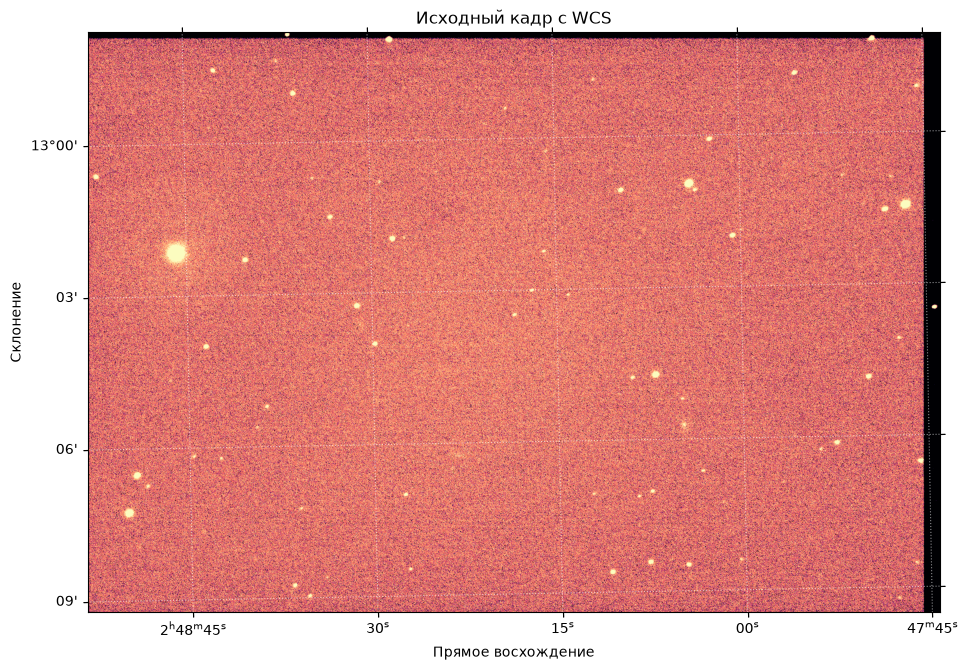

In [17]:
def display_norm(data):
    """Мягкая шкала, на которой видны и яркие, и слабые звёзды."""
    finite = data[np.isfinite(data)]
    low, high = np.percentile(finite, (5, 99.7))
    return ImageNormalize(vmin=low, vmax=high, stretch=AsinhStretch(a=0.08))

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection=wcs)
view = ax.imshow(image, origin="lower", norm=display_norm(image))
ax.coords.grid(color="white", linestyle=":", alpha=0.55)
ax.set_xlabel("Прямое восхождение")
ax.set_ylabel("Склонение")
ax.set_title("Исходный кадр с WCS")
asteroid = SkyCoord("02h48m18.45s", "+13d03m28.8s", frame="icrs")

x_ast, y_ast = wcs.world_to_pixel(asteroid)

# ax.scatter(
#       x_ast, y_ast,
#       s=260, marker="+", linewidths=2.2,
#       color="lime", label="(7065) Fredschaaf",
#   )

print(f"Астероид: x = {x_ast:.1f}, y = {y_ast:.1f}")

#plt.colorbar(view, ax=ax, label="счёт, ADU")
plt.show()

Выборка Gaia DR3 для тестового поля сохранена рядом с кадром в `exam/gaia_dr3_field.csv`.

In [4]:
start_time = Time(header["DATE-OBS"], format="isot", scale="utc")
if "DATE-END" in header:
    end_time = Time(header["DATE-END"], format="isot", scale="utc")
    mid_time = start_time + (end_time - start_time) / 2
else:
    mid_time = start_time + TimeDelta(float(header["EXPTIME"]) / 2, format="sec")

center_ra, center_dec = header["CRVAL1"], header["CRVAL2"]
MAG_MIN, MAG_MAX = 5.0, 16.5
CATALOG_PATH = ROOT / "exam" / "gaia_dr3_field.csv"

gaia = pd.read_csv(CATALOG_PATH)
gaia = gaia.dropna(subset=["ra", "dec", "pmra", "pmdec", "ref_epoch", "phot_g_mean_mag"])
gaia = gaia[gaia.phot_g_mean_mag.between(MAG_MIN, MAG_MAX)].copy()

# pmra в Gaia уже содержит cos(dec). Переводим mas/год в градусы.
years = mid_time.jyear - gaia.ref_epoch.to_numpy(float)
gaia["ra_at_epoch"] = gaia.ra + gaia.pmra * years / (3_600_000 * np.cos(np.deg2rad(gaia.dec)))
gaia["dec_at_epoch"] = gaia.dec + gaia.pmdec * years / 3_600_000

print(f"Каталог: {CATALOG_PATH.name}")
print(f"Эпоха середины экспозиции: {mid_time.isot}")
print(f"Gaia-звёзд в диапазоне {MAG_MIN} < G < {MAG_MAX}: {len(gaia)}")

Каталог: gaia_dr3_field.csv
Эпоха середины экспозиции: 2025-10-10T20:56:13.316
Gaia-звёзд в диапазоне 5.0 < G < 16.5: 143


Опорных звёзд внутри поля: 24


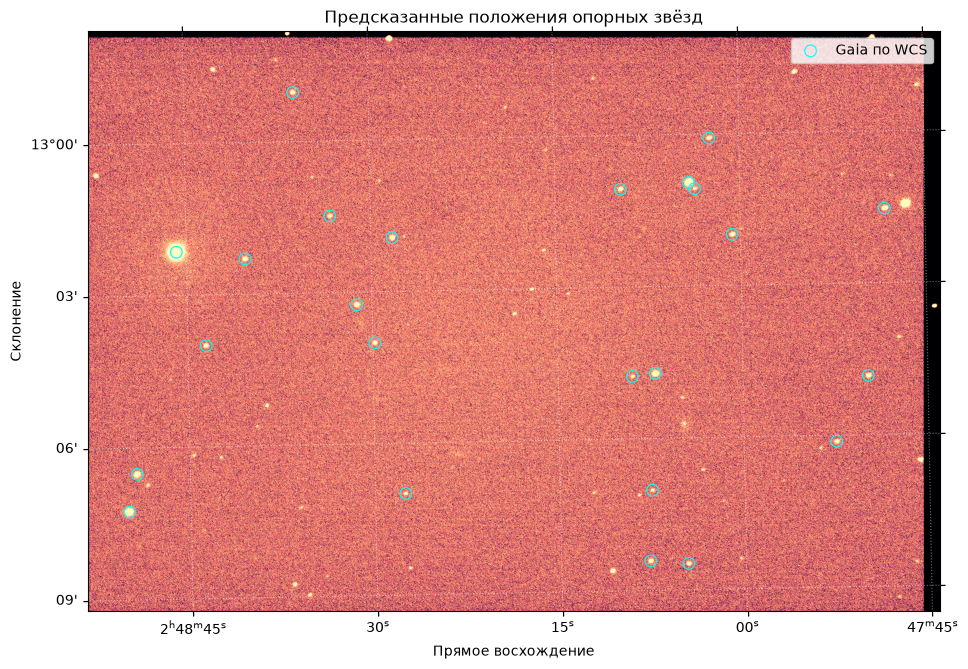

In [19]:
predicted_xy = wcs.all_world2pix(
    np.column_stack([gaia["ra_at_epoch"], gaia["dec_at_epoch"]]), 0,
)
MARGIN = 100
inside = (
    (predicted_xy[:, 0] > MARGIN) & (predicted_xy[:, 0] < width - MARGIN) &
    (predicted_xy[:, 1] > MARGIN) & (predicted_xy[:, 1] < height - MARGIN)
)

reference_stars = gaia.loc[inside].copy().reset_index(drop=True)
reference_stars[["x_wcs", "y_wcs"]] = predicted_xy[inside]
print(f"Опорных звёзд внутри поля: {len(reference_stars)}")

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection=wcs)
ax.imshow(image, origin="lower", norm=display_norm(image))
ax.scatter(reference_stars.x_wcs, reference_stars.y_wcs, s=70,
           facecolors="none", edgecolors="cyan", linewidths=0.8, label="Gaia по WCS")
ax.coords.grid(color="white", linestyle=":", alpha=0.45)
ax.set_xlabel("Прямое восхождение")
ax.set_ylabel("Склонение")
ax.legend(loc="upper right")
ax.set_title("Предсказанные положения опорных звёзд")
plt.show()

Для каждой опорной звезды берётся маленькое окно `21 × 21` пиксель. `centroid_2dg` подбирает в нём двумерный гаусс и возвращает центр звезды. Затем обычный метод наименьших квадратов строит линейную привязку к касательной плоскости.

In [23]:
HALF_BOX = 10


def centroid_star(data, x, y, half_box=10):
    """Центр звезды в небольшом окне; возвращает NaN, если окно не подходит."""
    x0, y0 = int(round(x)), int(round(y))
    cutout = data[y0-half_box:y0+half_box+1, x0-half_box:x0+half_box+1]
    if cutout.shape != (2 * half_box + 1, 2 * half_box + 1):
        return np.nan, np.nan
    try:
        cx, cy = centroid_2dg(cutout - np.nanmedian(cutout))
    except Exception:
        return np.nan, np.nan
    if not (np.isfinite(cx) and np.isfinite(cy) and 0 < cx < 2 * half_box and 0 < cy < 2 * half_box):
        return np.nan, np.nan
    return x0 - half_box + cx, y0 - half_box + cy


measured = []
for star in reference_stars.itertuples():
    x, y = centroid_star(image, star.x_wcs, star.y_wcs, HALF_BOX)
    if np.isfinite(x) and np.isfinite(y):
        measured.append((x, y, star.ra_at_epoch, star.dec_at_epoch, star.phot_g_mean_mag))

measured_all = pd.DataFrame(measured, columns=["x", "y", "ra", "dec", "gmag"])
print(f"Успешно измерены центры: {len(measured_all)}")
measured_all.head()

Успешно измерены центры: 24


,x,y,ra,dec,gmag
0,1379.754398,577.188420,42.029674,13.078616,13.461858
1,1461.289331,115.992468,42.019509,13.141345,15.585525
2,215.388459,872.108591,42.190855,13.035724,8.456452
3,1566.180201,915.248635,42.002835,13.033252,15.029251
4,1460.156202,1041.089820,42.017263,13.015928,12.264008


In [25]:
def tangent_plane(ra_deg, dec_deg, ra0_deg, dec0_deg):
    """Координаты ξ, η на касательной плоскости в градусах."""
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(ra0_deg), np.deg2rad(dec0_deg)
    denominator = np.sin(dec) * np.sin(dec0) + np.cos(dec) * np.cos(dec0) * np.cos(ra - ra0)
    xi = np.cos(dec) * np.sin(ra - ra0) / denominator
    eta = (np.sin(dec) * np.cos(dec0) - np.cos(dec) * np.sin(dec0) * np.cos(ra - ra0)) / denominator
    return np.rad2deg(xi), np.rad2deg(eta)


assert len(measured_all) > 3, "Недостаточно опорных звёзд для линейной модели."
all_stars = measured_all.copy()
all_stars["xi_deg"], all_stars["eta_deg"] = tangent_plane(
    all_stars.ra.to_numpy(), all_stars.dec.to_numpy(), center_ra, center_dec
)

# Выбираем локальную сетку вокруг ожидаемого положения астероида.
LOCAL_RADIUS_PX = 450
all_stars["distance_to_asteroid_px"] = np.hypot(all_stars.x - x_ast, all_stars.y - y_ast)
local_stars = all_stars[all_stars.distance_to_asteroid_px <= LOCAL_RADIUS_PX].copy()
outside_stars = all_stars[all_stars.distance_to_asteroid_px > LOCAL_RADIUS_PX].copy()
assert len(local_stars) > 3, "В локальной сетке недостаточно звёзд. Увеличьте LOCAL_RADIUS_PX."


def linear_result(stars):
    """Линейная привязка и её RMS для заданной сетки звёзд."""
    design = np.column_stack([np.ones(len(stars)), stars.x, stars.y])
    target = stars[["xi_deg", "eta_deg"]].to_numpy()
    coefficients, *_ = np.linalg.lstsq(design, target, rcond=None)
    residuals = (target - design @ coefficients) * 3_600_000
    train_rms = np.sqrt(np.mean(np.sum(residuals**2, axis=1)))
    adjusted_rms = np.sqrt(np.sum(residuals**2) / (len(stars) - 3))
    
    return coefficients, residuals, train_rms, adjusted_rms


all_result = linear_result(all_stars)
outside_result = linear_result(outside_stars)
local_result = linear_result(local_stars)
comparison = pd.DataFrame([
    ("Все опорные звёзды", len(all_stars), *all_result[2:]),
    ("Внешняя сетка без локальных звёзд", len(outside_stars), *outside_result[2:]),
    (f"Локальная сетка, r <= {LOCAL_RADIUS_PX} px", len(local_stars), *local_result[2:]),
], columns=["Сетка", "Звёзд", "RMS на опорных, mas", "RMS с учётом n-p, mas"])
display(comparison.style.format({
    "RMS на опорных, mas": "{:.1f}",
    "RMS с учётом n-p, mas": "{:.1f}",
}))

# Дальнейшие графики относятся только к локальной сетке.
coefficients, residual_mas, train_rms, adjusted_rms = local_result
plot_stars = local_stars.copy()
plot_stars["xi_residual_mas"] = residual_mas[:, 0]
plot_stars["eta_residual_mas"] = residual_mas[:, 1]
sigma_radial_mas = train_rms

print(f"Локальный радиус: {LOCAL_RADIUS_PX} px")
print(f"Всего измеренных звёзд: {len(all_stars)}")
print(f"Звёзд в локальной сетке: {len(local_stars)}")
print(f"Звёзд вне локальной сетки: {len(outside_stars)}")
print(f"RMS на опорных звёздах: {train_rms:.1f} mas")

,Сетка,Звёзд,"RMS на опорных, mas","RMS с учётом n-p, mas"
0,Все опорные звёзды,24,98.5,105.3
1,Внешняя сетка без локальных звёзд,18,103.1,112.9
2,"Локальная сетка, r <= 450 px",6,45.0,63.6


Локальный радиус: 450 px
Всего измеренных звёзд: 24
Звёзд в локальной сетке: 6
Звёзд вне локальной сетки: 18
RMS на опорных звёздах: 45.0 mas


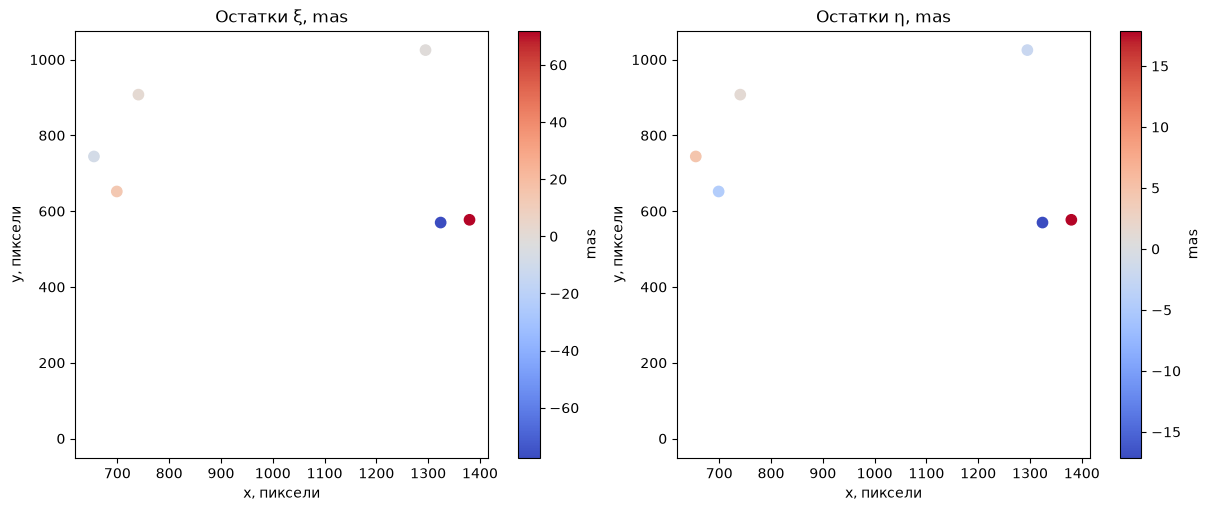

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, column, label in zip(
    axes,
    ["xi_residual_mas", "eta_residual_mas"],
    ["Остатки ξ, mas", "Остатки η, mas"],
):
    scatter = ax.scatter(plot_stars.x, plot_stars.y, c=plot_stars[column], s=55, cmap="coolwarm")
    ax.axhline(0, color="none")
    ax.set_xlabel("x, пиксели")
    ax.set_ylabel("y, пиксели")
    ax.set_title(label)
    plt.colorbar(scatter, ax=ax, label="mas")
plt.show()

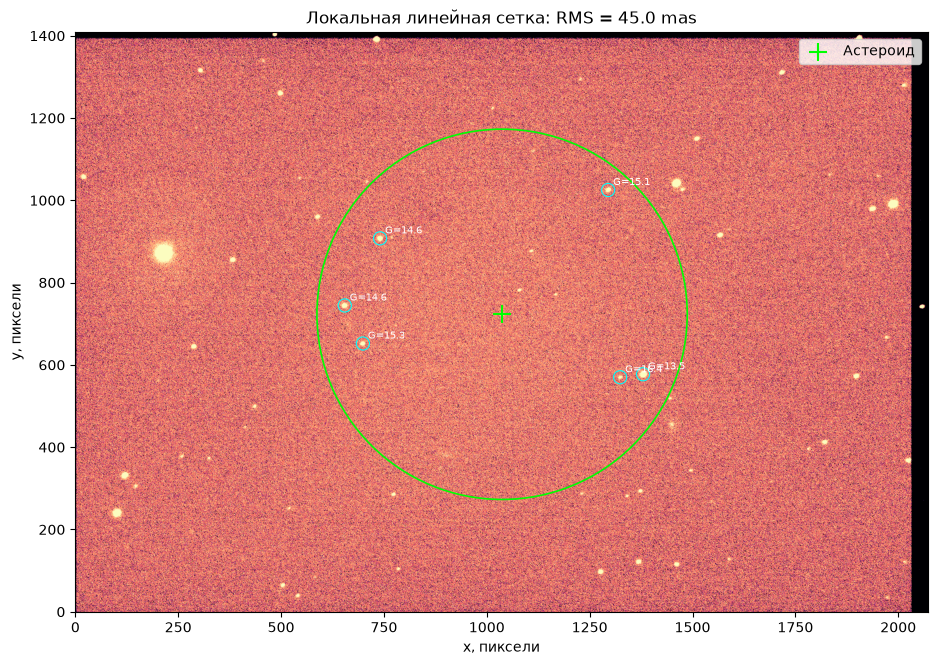

In [26]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(image, origin="lower", norm=display_norm(image))
ax.scatter(plot_stars.x, plot_stars.y, s=90, facecolors="none", edgecolors="cyan", linewidths=0.8)
for star in plot_stars.itertuples():
    ax.text(star.x + 12, star.y + 12, f"G={star.gmag:.1f}", color="white", fontsize=7)
ax.set_xlabel("x, пиксели")
ax.set_ylabel("y, пиксели")
circle = plt.Circle((x_ast, y_ast), LOCAL_RADIUS_PX, fill=False, color="lime", linewidth=1.2)
ax.add_patch(circle)
ax.scatter(x_ast, y_ast, marker="+", s=160, color="lime", label="Астероид")
ax.legend(loc="upper right")
ax.set_title(f"Локальная линейная сетка: RMS = {sigma_radial_mas:.1f} mas")
plt.show()